In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000389/rgb_100m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000389/tir_200m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000389/tir_100m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000118/rgb_100m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000118/tir_200m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000118/tir_100m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000396/rgb_100m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000396/tir_200m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000396/tir_100m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000131/rgb_100m.npy
/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000131/tir_200m.npy
/kaggle/in

In [2]:
!pip install pytorch-msssim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [3]:
# 2. Install/import libraries
import os, glob, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
assert device.type == "cuda", "GPU not detected — go to Runtime > Change runtime type > GPU"


Using device: cuda


In [4]:
import os as _os
print("Available inputs:", _os.listdir("/kaggle/input"))

DATASET_DIR = "/kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/"   # <-- CHANGE THIS to match your actual dataset slug + folder name above

assert os.path.isdir(DATASET_DIR), (
    f"Can't find {DATASET_DIR}. Check the printed list above for your dataset's exact slug name "
    f"and folder structure, then update DATASET_DIR to match."
)

sample_dirs = sorted([
    d for d in glob.glob(os.path.join(DATASET_DIR, "sample_*"))
    if os.path.isdir(d)
])

# Keep only samples that actually have both files we need for THIS model
valid_samples = []
for d in sample_dirs:
    if os.path.exists(os.path.join(d, "tir_100m.npy")) and os.path.exists(os.path.join(d, "rgb_100m.npy")):
        valid_samples.append(d)

print(f"Found {len(sample_dirs)} sample folders, {len(valid_samples)} have the tir_100m + rgb_100m pair we need.")
print("Example:", valid_samples[0] if valid_samples else "NONE FOUND - check DATASET_DIR")


Available inputs: ['datasets']
Found 400 sample folders, 400 have the tir_100m + rgb_100m pair we need.
Example: /kaggle/input/datasets/kartikeyavbyo/data-colorization/dataset/sample_000000


In [5]:
# Quick peek at shapes/ranges so normalization below is correct for YOUR data
sample_tir = np.load(os.path.join(valid_samples[0], "tir_100m.npy"))
sample_rgb = np.load(os.path.join(valid_samples[0], "rgb_100m.npy"))

print("tir_100m.npy  shape:", sample_tir.shape, "dtype:", sample_tir.dtype, "range:", sample_tir.min(), "to", sample_tir.max())
print("rgb_100m.npy  shape:", sample_rgb.shape, "dtype:", sample_rgb.dtype, "range:", sample_rgb.min(), "to", sample_rgb.max())


tir_100m.npy  shape: (512, 512) dtype: float32 range: 149.0 to 325.8894
rgb_100m.npy  shape: (3, 512, 512) dtype: float32 range: -0.20000003 to 0.36351368


In [6]:
random.seed(42)
shuffled = valid_samples.copy()
random.shuffle(shuffled)

split_idx = max(1, int(0.85 * len(shuffled)))
train_dirs = shuffled[:split_idx]
val_dirs = shuffled[split_idx:]

print(f"Train: {len(train_dirs)} samples | Val: {len(val_dirs)} samples")


Train: 340 samples | Val: 60 samples


In [7]:
class TIRColorizationDataset(Dataset):
    def __init__(self, sample_dirs, augment=False):
        self.sample_dirs = sample_dirs
        self.augment = augment

    def __len__(self):
        return len(self.sample_dirs)

    def __getitem__(self, idx):
        d = self.sample_dirs[idx]
        tir = np.load(os.path.join(d, "tir_100m.npy")).astype(np.float32)
        rgb = np.load(os.path.join(d, "rgb_100m.npy")).astype(np.float32)

        # normalize handling: ensure tir is (1, H, W)
        if tir.ndim == 2:
            tir = tir[None, :, :]
        # normalize rgb handling: ensure it's (3, H, W) not (H, W, 3)
        if rgb.shape[0] != 3 and rgb.shape[-1] == 3:
            rgb = rgb.transpose(2, 0, 1)

        # per-sample min-max normalize tir to [-1, 1]
        t_min, t_max = tir.min(), tir.max()
        tir_norm = (tir - t_min) / (t_max - t_min + 1e-8) * 2 - 1

        # rgb: clip then scale to [0, 1] using a robust per-sample range
        r_min, r_max = np.percentile(rgb, 1), np.percentile(rgb, 99)
        rgb_norm = np.clip((rgb - r_min) / (r_max - r_min + 1e-8), 0, 1)

        if self.augment:
            if random.random() > 0.5:
                tir_norm = tir_norm[:, :, ::-1].copy()
                rgb_norm = rgb_norm[:, :, ::-1].copy()
            if random.random() > 0.5:
                tir_norm = tir_norm[:, ::-1, :].copy()
                rgb_norm = rgb_norm[:, ::-1, :].copy()

        return torch.from_numpy(tir_norm).float(), torch.from_numpy(rgb_norm).float()


train_ds = TIRColorizationDataset(train_dirs, augment=True)
val_ds = TIRColorizationDataset(val_dirs, augment=False)

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

tir_batch, rgb_batch = next(iter(train_loader))
print("TIR batch:", tir_batch.shape, "| RGB batch:", rgb_batch.shape)


TIR batch: torch.Size([8, 1, 512, 512]) | RGB batch: torch.Size([8, 3, 512, 512])


In [8]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, down=True, dropout=False):
        super().__init__()
        layers = []
        if down:
            layers += [nn.Conv2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2, inplace=True)]
        else:
            layers += [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)]
            if dropout:
                layers.append(nn.Dropout(0.3))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class TIRToRGBGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = ConvBlock(1, 64)
        self.d2 = ConvBlock(64, 128)
        self.d3 = ConvBlock(128, 256)
        self.d4 = ConvBlock(256, 512)
        self.d5 = ConvBlock(512, 512)

        self.u1 = ConvBlock(512, 512, down=False, dropout=True)
        self.u2 = ConvBlock(512 + 512, 256, down=False, dropout=True)
        self.u3 = ConvBlock(256 + 256, 128, down=False)
        self.u4 = ConvBlock(128 + 128, 64, down=False)
        self.u5 = nn.ConvTranspose2d(64 + 64, 3, 4, 2, 1)

    def forward(self, x):
        d1 = self.d1(x); d2 = self.d2(d1); d3 = self.d3(d2); d4 = self.d4(d3); d5 = self.d5(d4)
        u1 = self.u1(d5)
        u2 = self.u2(torch.cat([u1, d4], dim=1))
        u3 = self.u3(torch.cat([u2, d3], dim=1))
        u4 = self.u4(torch.cat([u3, d2], dim=1))
        out = self.u5(torch.cat([u4, d1], dim=1))
        return torch.sigmoid(out)


model = TIRToRGBGenerator().to(device)
print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters")


Model has 16,660,611 parameters


In [9]:
!pip install pytorch-msssim -q
from pytorch_msssim import ssim as ssim_fn

def combined_loss(pred, target, l1_weight=1.0, ssim_weight=1.0):
    l1 = torch.nn.functional.l1_loss(pred, target)
    s = 1 - ssim_fn(pred, target, data_range=1.0, size_average=True)
    return l1_weight * l1 + ssim_weight * s

EPOCHS = 80
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
history = {"train_loss": [], "val_loss": []}


In [10]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for tir, rgb in loader:
            tir, rgb = tir.to(device), rgb.to(device)
            pred = model(tir)
            loss = combined_loss(pred, rgb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * tir.size(0); n += tir.size(0)
    return total / max(n, 1)

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, True)
    vl = run_epoch(val_loader, False)
    scheduler.step(vl)
    history["train_loss"].append(tr); history["val_loss"].append(vl)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | train: {tr:.4f} | val: {vl:.4f}")


Epoch   1/80 | train: 1.0240 | val: 0.9269
Epoch   5/80 | train: 0.7451 | val: 0.8085
Epoch  10/80 | train: 0.7035 | val: 0.7471
Epoch  15/80 | train: 0.6577 | val: 0.7566
Epoch  20/80 | train: 0.6267 | val: 0.7308
Epoch  25/80 | train: 0.6209 | val: 0.6466
Epoch  30/80 | train: 0.6230 | val: 0.6606
Epoch  35/80 | train: 0.6174 | val: 0.6791
Epoch  40/80 | train: 0.6146 | val: 0.6336
Epoch  45/80 | train: 0.6005 | val: 0.6436
Epoch  50/80 | train: 0.6053 | val: 0.6393
Epoch  55/80 | train: 0.5963 | val: 0.6248
Epoch  60/80 | train: 0.5940 | val: 0.6524
Epoch  65/80 | train: 0.5907 | val: 0.6356
Epoch  70/80 | train: 0.5899 | val: 0.6185
Epoch  75/80 | train: 0.5901 | val: 0.6216
Epoch  80/80 | train: 0.5807 | val: 0.7075


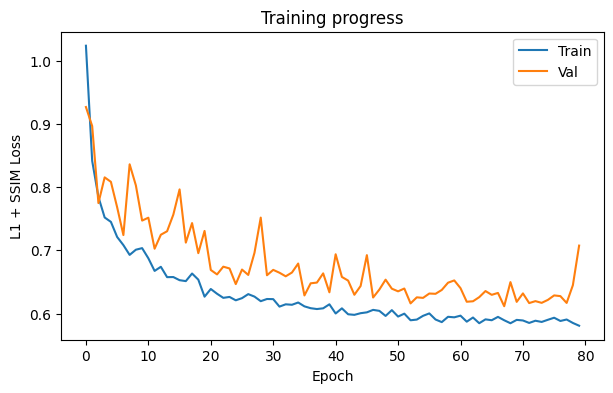

In [11]:
# 9. Loss curve
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.xlabel("Epoch"); plt.ylabel("L1 + SSIM Loss"); plt.title("Training progress"); plt.legend()
plt.show()


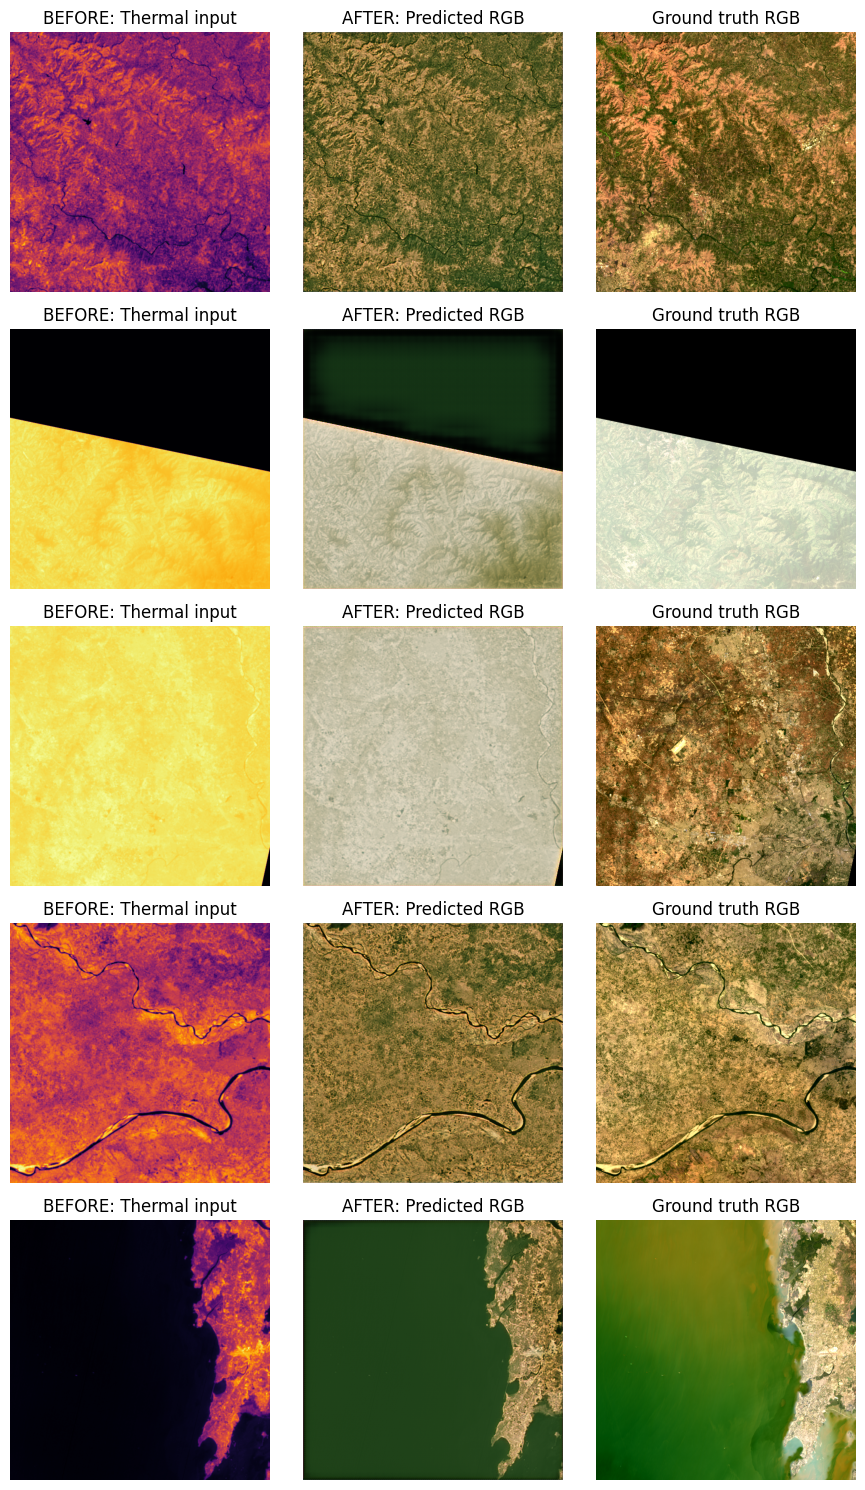

In [12]:
model.eval()
n_show = 5
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3*n_show))

with torch.no_grad():
    for i in range(n_show):
        tir, rgb_true = val_ds[i]
        pred = model(tir.unsqueeze(0).to(device)).squeeze(0).cpu()

        tir_img = (tir.squeeze(0).numpy() + 1) / 2
        true_img = rgb_true.numpy().transpose(1, 2, 0)
        pred_img = np.clip(pred.numpy().transpose(1, 2, 0), 0, 1)

        axes[i,0].imshow(tir_img, cmap="inferno"); axes[i,0].set_title("BEFORE: Thermal input")
        axes[i,1].imshow(pred_img); axes[i,1].set_title("AFTER: Predicted RGB")
        axes[i,2].imshow(true_img); axes[i,2].set_title("Ground truth RGB")
        for ax in axes[i]: ax.axis("off")

plt.tight_layout()
plt.show()



In [13]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim_metric

psnr_scores, ssim_scores = [], []
model.eval()
with torch.no_grad():
    for tir, rgb_true in val_loader:
        pred = model(tir.to(device)).cpu()
        for i in range(tir.size(0)):
            t = rgb_true[i].numpy().transpose(1,2,0)
            p = np.clip(pred[i].numpy().transpose(1,2,0), 0, 1)
            psnr_scores.append(psnr(t, p, data_range=1.0))
            ssim_scores.append(ssim_metric(t, p, channel_axis=2, data_range=1.0))

print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
print(f"Average SSIM: {np.mean(ssim_scores):.4f}")


Average PSNR: 14.71 dB
Average SSIM: 0.4623


In [14]:
SAVE_PATH = "/kaggle/working/tir_to_rgb_model.pth"
torch.save(model.state_dict(), SAVE_PATH)
print("Saved to", SAVE_PATH)

# To reload later:
# model = TIRToRGBGenerator().to(device)
# model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
# model.eval()


Saved to /kaggle/working/tir_to_rgb_model.pth
